In [2]:
!pip install networkx numpy scipy scikit-learn

In [6]:
import pandas as pd
import networkx as nx

# Load datasets
edges_df = pd.read_csv("/content/Phone_Calls.csv", header=None)   # or Meetings
# Assuming the first two columns are source and target, and the third is a weight.
edges_df.columns = ['Source', 'Target', 'Weight']
nodes_df = pd.read_csv("/content/Sicilian Mafia.csv")
roles_df = pd.read_csv("/content/Roles.csv")

# Build graph
G = nx.Graph()

# Add edges (adjust column names if needed)
G.add_edges_from(edges_df[['Source', 'Target']].values)

# Add node attributes (optional)
for _, row in roles_df.iterrows():
    node_id = row['Node']
    if node_id in G.nodes:
        G.nodes[node_id]['role'] = row['Role']

nodes = list(G.nodes())
n = len(nodes)

print(f"Number of nodes: {n}")
print(f"Number of edges: {G.number_of_edges()}")

Number of nodes: 94
Number of edges: 120


In [7]:
import numpy as np

def initialize_population(pop_size, num_nodes, num_communities):
    return [np.random.randint(0, num_communities, num_nodes) for _ in range(pop_size)]

In [16]:
from networkx.algorithms.community.quality import modularity

def get_communities(G, chromosome):
    communities = {}
    node_labels = list(G.nodes()) # Get actual node labels in consistent order
    for i, comm in enumerate(chromosome):
        actual_node = node_labels[i] # Map chromosome index to actual node label
        communities.setdefault(comm, []).append(actual_node)
    return list(communities.values())

# Objective 1: Maximize modularity
def objective1(G, chromosome):
    return modularity(G, get_communities(G, chromosome))

# Objective 2: Minimize number of communities
def objective2(chromosome):
    return len(set(chromosome))

In [9]:
def decoding(G, chromosome):
    for i in range(len(chromosome)):
        for j in set(chromosome):
            temp = chromosome.copy()
            temp[i] = j

            if objective1(G, temp) > objective1(G, chromosome):
                chromosome = temp
    return chromosome

In [10]:
import random

def dominates(a, b):
    return (a[0] >= b[0] and a[1] <= b[1]) and (a[0] > b[0] or a[1] < b[1])

def tournament_selection(pop, fitness):
    i, j = random.sample(range(len(pop)), 2)
    if dominates(fitness[i], fitness[j]):
        return pop[i]
    return pop[j]

In [11]:
def crossover(p1, p2):
    point = np.random.randint(1, len(p1)-1)
    return np.concatenate([p1[:point], p2[point:]])

def mutation(chromosome, num_communities, rate=0.1):
    for i in range(len(chromosome)):
        if np.random.rand() < rate:
            chromosome[i] = np.random.randint(0, num_communities)
    return chromosome

In [12]:
def non_dominated_sort(fitness):
    fronts = [[]]
    domination_count = [0]*len(fitness)
    dominated_solutions = [[] for _ in range(len(fitness))]

    for i in range(len(fitness)):
        for j in range(len(fitness)):
            if dominates(fitness[i], fitness[j]):
                dominated_solutions[i].append(j)
            elif dominates(fitness[j], fitness[i]):
                domination_count[i] += 1

        if domination_count[i] == 0:
            fronts[0].append(i)

    i = 0
    while fronts[i]:
        next_front = []
        for p in fronts[i]:
            for q in dominated_solutions[p]:
                domination_count[q] -= 1
                if domination_count[q] == 0:
                    next_front.append(q)
        i += 1
        fronts.append(next_front)

    return fronts[:-1]

In [13]:
def crowding_distance(front, fitness):
    distance = [0]*len(front)

    for m in range(2):  # two objectives
        values = [fitness[i][m] for i in front]
        sorted_idx = np.argsort(values)

        distance[sorted_idx[0]] = distance[sorted_idx[-1]] = float('inf')

        for i in range(1, len(front)-1):
            distance[sorted_idx[i]] += (
                values[sorted_idx[i+1]] - values[sorted_idx[i-1]]
            )

    return distance

In [14]:
import time

def moea_sa_ov(G, pop_size=20, generations=30, num_communities=5):

    start_time = time.time()

    num_nodes = G.number_of_nodes()
    population = initialize_population(pop_size, num_nodes, num_communities)

    for gen in range(generations):

        # Decode & evaluate
        fitness = []
        for i in range(len(population)):
            population[i] = decoding(G, population[i])
            fitness.append((objective1(G, population[i]),
                            objective2(population[i])))

        # Generate offspring
        offspring = []
        while len(offspring) < pop_size:
            p1 = tournament_selection(population, fitness)
            p2 = tournament_selection(population, fitness)

            child = crossover(p1, p2)
            child = mutation(child, num_communities)
            offspring.append(child)

        # Combine populations
        combined = population + offspring

        combined_fitness = [
            (objective1(G, ind), objective2(ind)) for ind in combined
        ]

        # Non-dominated sorting
        fronts = non_dominated_sort(combined_fitness)

        new_population = []

        for front in fronts:
            if len(new_population) + len(front) > pop_size:
                dist = crowding_distance(front, combined_fitness)
                sorted_front = [x for _, x in sorted(zip(dist, front), reverse=True)]
                new_population.extend([combined[i] for i in sorted_front[:pop_size-len(new_population)]])
                break
            else:
                new_population.extend([combined[i] for i in front])

        population = new_population

        print(f"Generation {gen+1} completed")

    runtime = time.time() - start_time

    return population, runtime

In [17]:
solutions, runtime = moea_sa_ov(G)

print("Runtime:", runtime)

Generation 1 completed
Generation 2 completed
Generation 3 completed
Generation 4 completed
Generation 5 completed
Generation 6 completed
Generation 7 completed
Generation 8 completed
Generation 9 completed
Generation 10 completed
Generation 11 completed
Generation 12 completed
Generation 13 completed
Generation 14 completed
Generation 15 completed
Generation 16 completed
Generation 17 completed
Generation 18 completed
Generation 19 completed
Generation 20 completed
Generation 21 completed
Generation 22 completed
Generation 23 completed
Generation 24 completed
Generation 25 completed
Generation 26 completed
Generation 27 completed
Generation 28 completed
Generation 29 completed
Generation 30 completed
Runtime: 142.40557551383972


In [18]:
best = max(solutions, key=lambda x: objective1(G, x))

print("Best Modularity:", objective1(G, best))
print("Communities:", len(set(best)))

Best Modularity: 0.5864236111111111
Communities: 5


In [19]:
import matplotlib.pyplot as plt

def plot_pareto_front(G, solutions):

    modularity_vals = []
    community_counts = []

    for sol in solutions:
        modularity_vals.append(objective1(G, sol))
        community_counts.append(len(set(sol)))

    plt.figure(figsize=(8, 6))

    plt.scatter(community_counts, modularity_vals)

    plt.xlabel("Number of Communities")
    plt.ylabel("Modularity")
    plt.title("Pareto Front (MOEA-SA_OV)")

    plt.show()

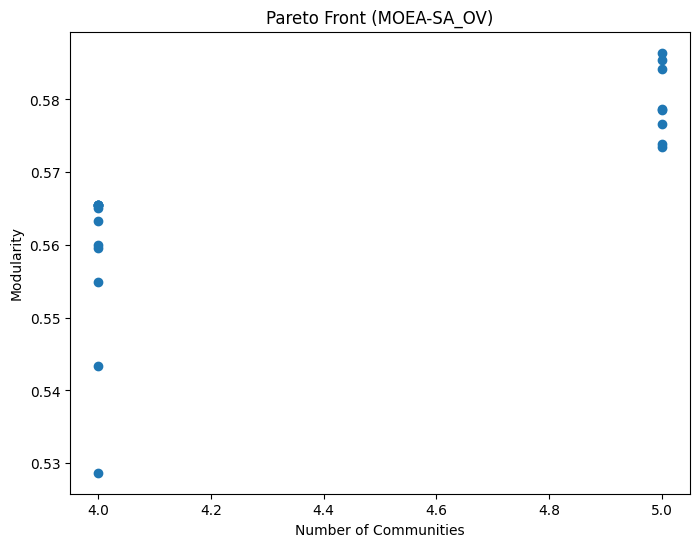

In [20]:
plot_pareto_front(G, solutions)

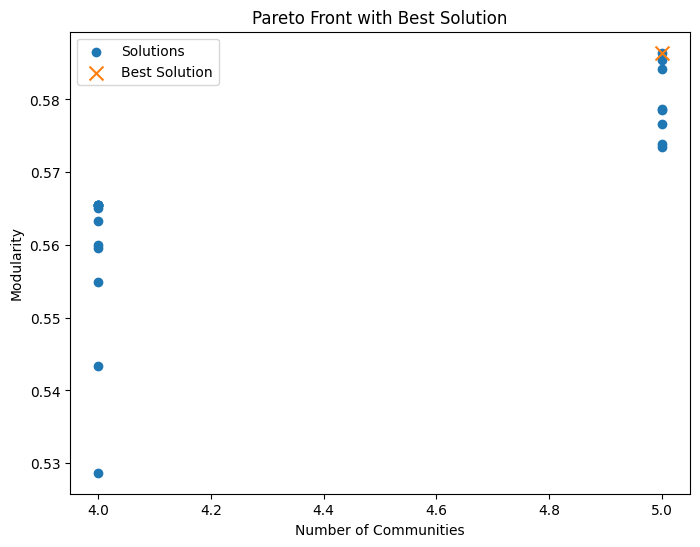

In [21]:
best = max(solutions, key=lambda x: objective1(G, x))

best_mod = objective1(G, best)
best_comm = len(set(best))

plt.figure(figsize=(8,6))

mods = [objective1(G, s) for s in solutions]
comms = [len(set(s)) for s in solutions]

plt.scatter(comms, mods, label="Solutions")
plt.scatter(best_comm, best_mod, marker='x', s=100, label="Best Solution")

plt.xlabel("Number of Communities")
plt.ylabel("Modularity")
plt.title("Pareto Front with Best Solution")
plt.legend()

plt.show()

In [22]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def visualize_unweighted_graph(G, labels, title="Unweighted Community Graph"):

    plt.figure(figsize=(10, 8))

    # Use a clean layout
    pos = nx.spring_layout(G, seed=42)

    unique_labels = np.unique(labels)
    colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))

    # Draw nodes with colors (communities)
    for color, label in zip(colors, unique_labels):
        node_list = [node for node in range(len(labels)) if labels[node] == label]

        nx.draw_networkx_nodes(
            G, pos,
            nodelist=node_list,
            node_color=[color],
            node_size=80
        )

    # Draw edges (UNWEIGHTED → all same style)
    nx.draw_networkx_edges(
        G, pos,
        alpha=0.3,     # light edges
        width=1        # uniform width
    )

    plt.title(title)
    plt.axis("off")  # cleaner look
    plt.show()

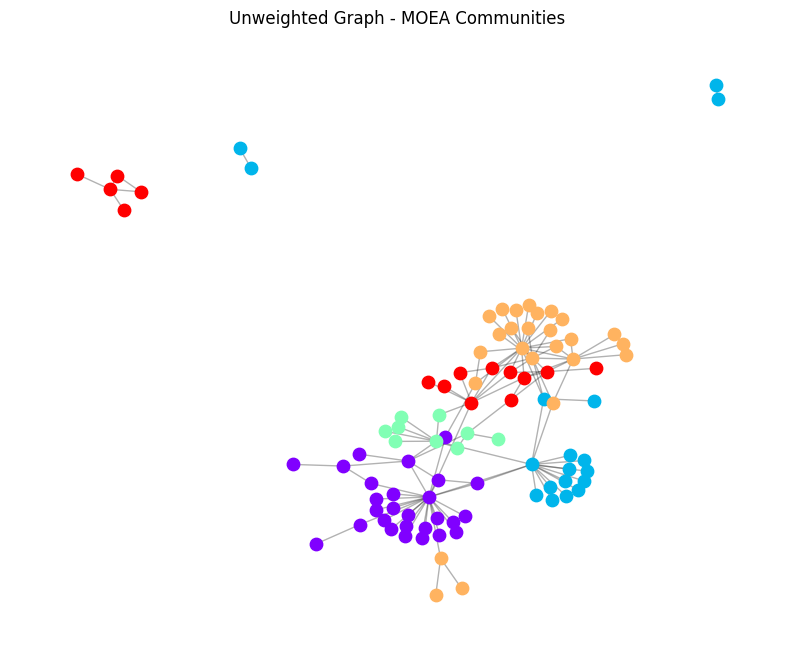

In [24]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def visualize_unweighted_graph(G, labels, title="Unweighted Community Graph"):

    plt.figure(figsize=(10, 8))

    # Use a clean layout
    pos = nx.spring_layout(G, seed=42)

    unique_labels = np.unique(labels)
    colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))

    # Get the actual node labels from the graph G, in the same order as `labels` array
    node_labels_from_G = list(G.nodes())

    # Draw nodes with colors (communities)
    for color, label in zip(colors, unique_labels):
        # Construct node_list using actual string node labels
        node_list = [node_labels_from_G[i] for i, comm_id in enumerate(labels) if comm_id == label]

        nx.draw_networkx_nodes(
            G, pos,
            nodelist=node_list,
            node_color=[color],
            node_size=80
        )

    # Draw edges (UNWEIGHTED → all same style)
    nx.draw_networkx_edges(
        G, pos,
        alpha=0.3,
        width=1
    )

    plt.title(title)
    plt.axis("off")  # cleaner look
    plt.show()

visualize_unweighted_graph(G, best, title="Unweighted Graph - MOEA Communities")